# Download statistics for machine-learning libraries from Anaconda

This notebook aggregates some package download stats accross anaconda sources.
pypi sources can be inspected online, eg on [clickpy](https://clickpy.clickhouse.com/dashboard/scikit-learn)
Note that some packages (eg tensorflow) explicitely recommend to use pip rather than conda

Upstream [README](https://github.com/ContinuumIO/anaconda-package-data/blob/master/README.md#quickstart).

The following packages are useful to install to run it: intake, dask, requests, aiohttp, pyarrow, intake-parquet, s3fs, matplotlib, joblib

In [1]:
# Import necessary libraries
import intake
import dask
import pandas as pd
import joblib

In [2]:
# Get the data
cat = intake.open_catalog('https://raw.githubusercontent.com/anaconda/anaconda-package-data/master/catalog/anaconda_package_data.yaml')

In [3]:
# required variable assignments
years = range(2023, 2026)
packages = ["scikit-learn", "pytorch", "cuml", "tensorflow", "py-xgboost", "lightgbm", "catboost"]

#data_source = "anaconda"

In [4]:
# Initialize the dataframe to store the results
downloads_conda = pd.DataFrame({
    "pkg_name": [],
    "year": [],
    "downloads": [
    ]
})

# Download the data for each year and package, and aggregate per year
for year in years:
    print(year)
    df_year_monthly_res = cat.anaconda_package_data_by_year_month_res(year=year).to_dask().compute()
    for pkg_name in packages:
        pkg_year = df_year_monthly_res[
                (df_year_monthly_res["pkg_name"] == pkg_name)
                #& (df_year_monthly_res["data_source"] == data_source)   
            ].reset_index(drop=True)['counts'].sum()
        downloads_conda = pd.concat([downloads_conda, pd.DataFrame({
            "pkg_name": [pkg_name],
            "year": [year],
            "downloads": [pkg_year]
        })], ignore_index=True)

2023
2024
2025


In [5]:
downloads_conda['year'] = downloads_conda['year'].astype(int)
downloads_conda['downloads'] = downloads_conda['downloads'].astype(int)
downloads_conda.to_csv("anaconda_downloads.csv", index=False)
downloads_conda

,pkg_name,year,downloads
0,scikit-learn,2023,15485322
1,pytorch,2023,11001560
2,cuml,2023,171191
3,tensorflow,2023,2432514
4,py-xgboost,2023,2585041
5,lightgbm,2023,1022345
6,catboost,2023,325039
7,scikit-learn,2024,19750039
8,pytorch,2024,11969746
9,cuml,2024,336401


In [6]:
 # Pivot the dataframe to have years as columns and package names as index
pivot_df = downloads_conda.pivot(index='pkg_name', columns='year', values='downloads')
pivot_df

year,2023,2024,2025
pkg_name,,,
catboost,325039,369808,463451
cuml,171191,336401,145292
lightgbm,1022345,1431388,2636069
py-xgboost,2585041,4795679,5129384
pytorch,11001560,11969746,11595039
scikit-learn,15485322,19750039,23826374
tensorflow,2432514,1793509,1745782


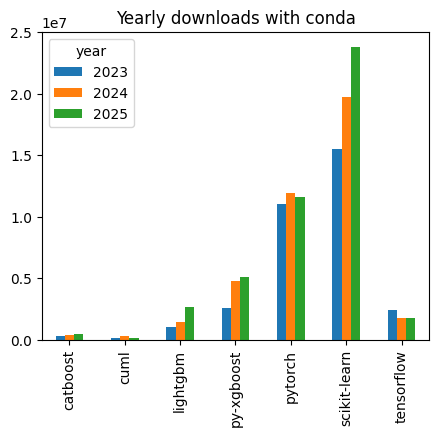

In [7]:
# Use the pivoted dataframe to create a bar plot
pivot_df.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda')
from matplotlib import pyplot as plt
plt.xlabel("");

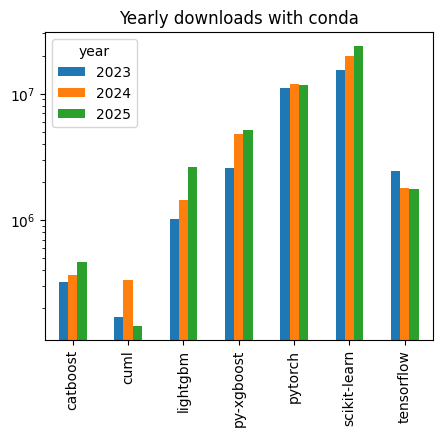

In [8]:
# Same but in log scale, to facilate the comparison of the packages with lower download counts
pivot_df.plot(kind='bar', figsize=(5, 4), title='Yearly downloads with conda')
ax = plt.gca()
ax.set_yscale('log')
plt.xlabel("");

In [9]:
# Let's check which channels we have covered
list(df_year_monthly_res['data_source'].unique())

['conda-forge',
 'rapidsai-nightly',
 'bioconda',
 'nvidia',
 'anaconda',
 'rapidsai',
 'pytorch',
 'pyviz',
 'pytorch-test',
 'plotly',
 'rdkit']

# Now with pypistats

In [ ]:
import requests

CACHE_TTL_SECONDS = 24 * 60 * 60  # 24 hours

mem = joblib.Memory("joblib_cache", verbose=3)

@mem.cache
def fetch_pypi_stats(package_name):
    url = f"https://pypistats.org/api/packages/{package_name}/overall"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return response.json()



yearly_downloads = {}

for entry in data["data"]:
    year = int(entry["date"][:4])
    if year >= start_year:
        yearly_downloads.setdefault(year, 0)
        yearly_downloads[year] += entry["downloads"]

downloads = dict(sorted(yearly_downloads.items()))
